# Window-mean univariate (spatial explorer)

Exploratory spatial maps for phase-window mean univariate results (`*Mean*.csv`).
Data live under `../results/{task}(bipolar)(hammers)/univariate/`.

Each selected spec renders **two** inline panels:
1. **Insula zoom** (superior insula, bilateral)
2. **Whole brain** (bilateral lateral pial views)

Figures are displayed inline only (no file export). Style follows
[`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md).

In [8]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.univariate.viz_mean import (
    BrainSurfaceContext,
    DEFAULT_TASKS,
    attach_metadata,
    filter_qc,
    load_coord_metadata,
    load_mean_contrasts,
    plot_signed_electrodes_brain,
    roi_counts,
    select_significant,
)

In [9]:
cm = 1 / 2.54
plt.rcParams['svg.fonttype'] = 'none'
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

mne.viz.set_3d_backend('notebook')

'notebook'

## Config

Edit `FIGURE_SPECS` to batch-preview task × phase × contrast combinations.

In [10]:
TASKS = list(DEFAULT_TASKS)
RESULTS_DIR = ROOT / 'results'

FIGURE_SPECS = [
    ('LexicalDelay', 'delay', 'DecisionVsRepeatMean'),
    ('LexicalDelay', 'response', 'DecisionVsRepeatMean'),
    ('LexicalNoDelay', 'response', 'DecisionVsRepeatMean'),
]

PREVIEW_TASK, PREVIEW_PHASE, PREVIEW_CONTRAST = FIGURE_SPECS[0]


def parse_figure_spec(spec):
    if len(spec) != 3:
        raise ValueError(f'FIGURE_SPECS entries must be (task, phase, contrast); got {spec!r}')
    return spec

## Load mean contrasts + Hammers coordinates

In [11]:
mean_df = load_mean_contrasts(RESULTS_DIR, tasks=TASKS)
coords = load_coord_metadata(RESULTS_DIR, tasks=TASKS)
mean_df = attach_metadata(mean_df, coords)
mean_qc = filter_qc(mean_df)

print(f'Mean rows: {len(mean_df):,} | after QC: {len(mean_qc):,}')
print(f'Coord channels: {coords.channel.nunique():,}')
print(f'Tasks: {sorted(mean_qc.task.dropna().unique())}')
print(f'Contrasts: {sorted(mean_qc.contrast.dropna().unique())}')

Mean rows: 125,918 | after QC: 49,866
Coord channels: 8,489
Tasks: ['LexicalDelay', 'LexicalNoDelay']
Contrasts: ['DecisionVsRepeatMean', 'WordVsNonwordDecisionMean', 'WordVsNonwordRepeatMean']


## Preview one spec

In [12]:
preview_sig = select_significant(
    mean_qc,
    phase=PREVIEW_PHASE,
    contrast=PREVIEW_CONTRAST,
    tasks=[PREVIEW_TASK],
)

print(
    f'{PREVIEW_TASK} | {PREVIEW_PHASE} | {PREVIEW_CONTRAST}: '
    f'{preview_sig.channel.nunique()} significant channels across '
    f'{preview_sig.subject.nunique()} subjects'
)
display(preview_sig.head())
display(roi_counts(preview_sig).to_frame('n_channels'))

LexicalDelay | delay | DecisionVsRepeatMean: 542 significant channels across 47 subjects


,subject,phase,contrast,channel,n_a,n_b,mean_a,mean_b,sem_a,sem_b,...,task,processing,roi,hemi,label,x,y,z,mix,direction
0,D0023,delay,DecisionVsRepeatMean,D0023_RAMF8-9,139,154,-0.027323,-0.216560,0.040190,0.035469,...,LexicalDelay,Delay,CG,Mixed,CG anterior cingulate gyrus R,2.30083,54.24120,8.2190,False,Decision
1,D0023,delay,DecisionVsRepeatMean,D0023_RPSF4-5,139,154,0.061266,-0.090822,0.037903,0.027055,...,LexicalDelay,Delay,CG,R,CG posterior cingulate gyrus R,9.57564,4.03650,21.2074,False,Decision
2,D0023,delay,DecisionVsRepeatMean,D0023_RPSF8-9,139,154,0.090018,-0.103362,0.040558,0.036300,...,LexicalDelay,Delay,SFG,R,FL superior frontal gyrus R,12.96190,8.57126,36.0513,False,Decision
3,D0024,delay,DecisionVsRepeatMean,D0024_LOF3-4,127,140,-0.244481,-0.416250,0.040558,0.034174,...,LexicalDelay,Delay,OFC,L,FL posterior orbital gyrus L,-29.26790,46.32240,-36.5153,False,Decision
4,D0024,delay,DecisionVsRepeatMean,D0024_LPST3-4,127,138,0.562504,0.286575,0.056527,0.041788,...,LexicalDelay,Delay,pTL,L,TL posterior temporal lobe L,-41.13620,-25.41290,-41.6831,False,Decision


,n_channels
roi,
MFG,64
pTL,60
OFC,40
SFG,33
MTG,33
IFG,29
AIC,29
STGp,25
CG,20


## Spatial maps (preview spec)

Signed color = `mean_diff` (red positive arm, blue negative arm).

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-18 13:53:30.293 ( 360.004s) [    7F04486D3740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xce2d510): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card

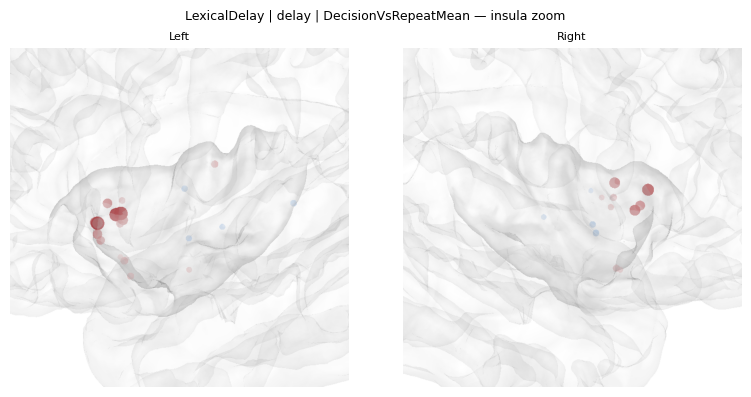

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-18 13:53:31.781 ( 361.492s) [    7F04486D3740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x103bab40): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

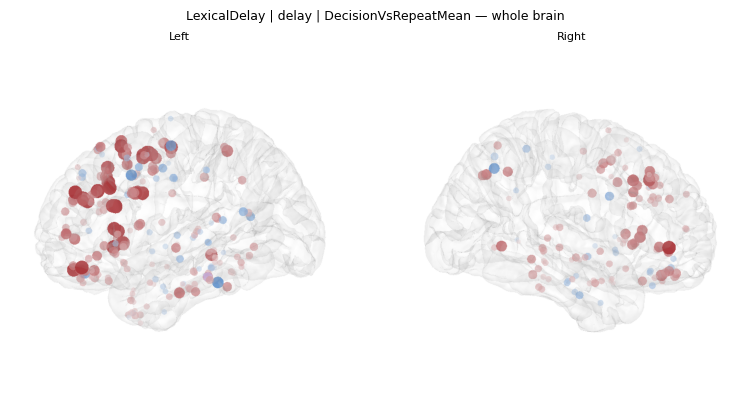

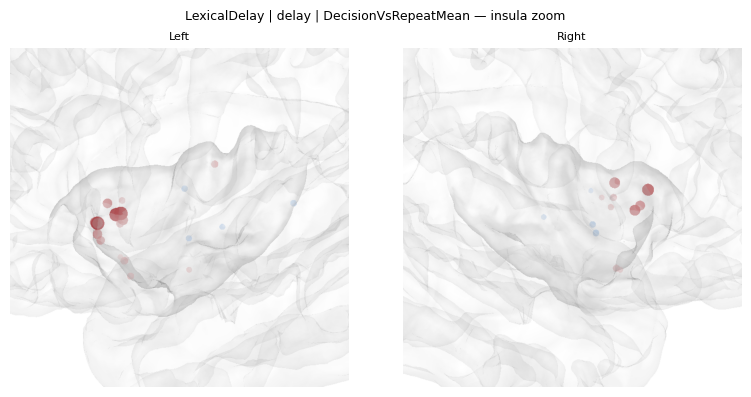

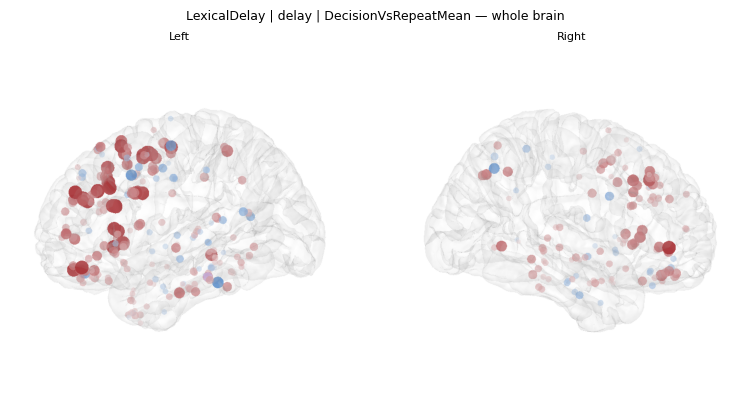

In [13]:
brain_ctx = BrainSurfaceContext()
preview_title = f'{PREVIEW_TASK} | {PREVIEW_PHASE} | {PREVIEW_CONTRAST}'

fig_insula = plot_signed_electrodes_brain(
    preview_sig,
    view_mode='insula',
    title=f'{preview_title} — insula zoom',
    ctx=brain_ctx,
    red=red,
    blue=blue,
)
display(fig_insula)

fig_whole = plot_signed_electrodes_brain(
    preview_sig,
    view_mode='wholebrain',
    title=f'{preview_title} — whole brain',
    ctx=brain_ctx,
    red=red,
    blue=blue,
)
display(fig_whole)

## Batch preview all `FIGURE_SPECS`

LexicalDelay | delay | DecisionVsRepeatMean (n=542)


,n_channels
roi,
MFG,64
pTL,60
OFC,40
SFG,33
MTG,33
IFG,29
AIC,29
STGp,25
CG,20


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-18 13:53:34.577 ( 364.288s) [    7F04486D3740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xeb78160): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card

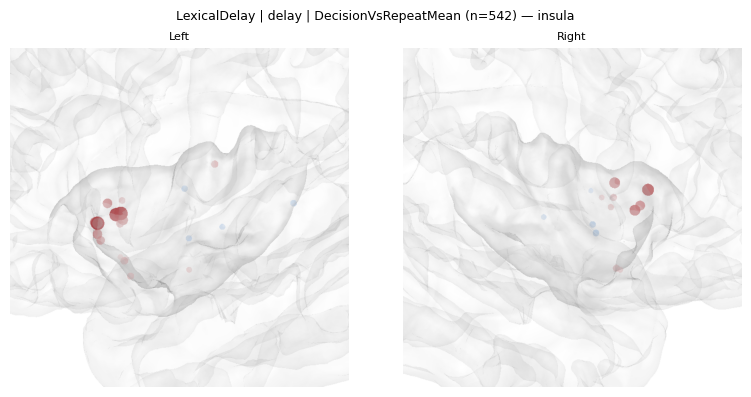

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-18 13:53:36.063 ( 365.774s) [    7F04486D3740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xe154210): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card

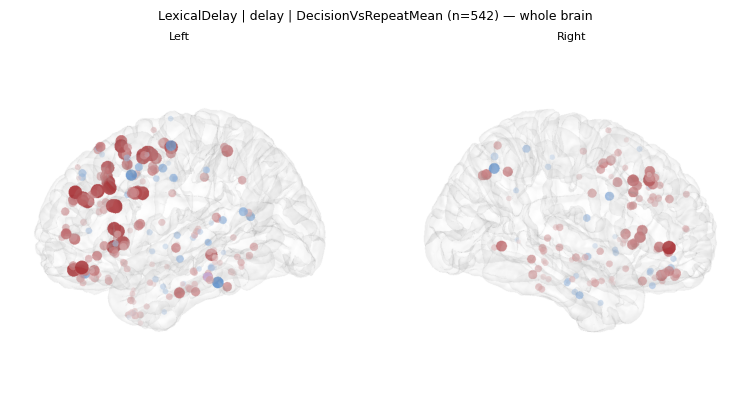

LexicalDelay | response | DecisionVsRepeatMean (n=1110)


,n_channels
roi,
pTL,119
STGp,115
MTG,97
MFG,66
IFG,59
OFC,49
TP,45
PrG,41
SFG,39


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-18 13:53:37.967 ( 367.678s) [    7F04486D3740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xf10d0d0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card

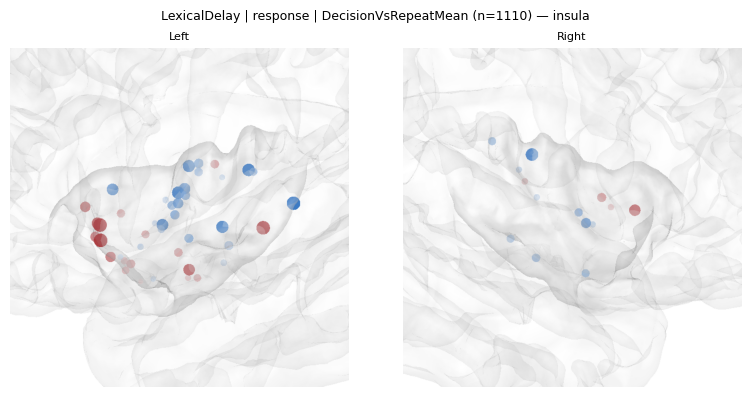

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-18 13:53:39.476 ( 369.187s) [    7F04486D3740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xf10d0d0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card

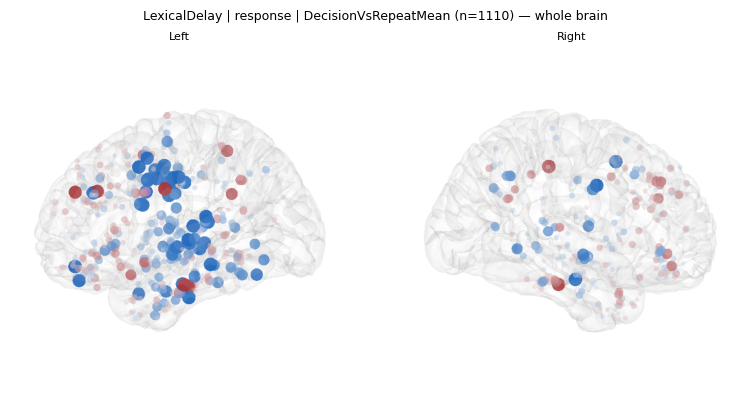

LexicalNoDelay | response | DecisionVsRepeatMean (n=578)


,n_channels
roi,
pTL,81
MTG,59
STGp,56
TP,40
MFG,38
OFC,27
AIC,22
PrG,21
SMG,20


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-18 13:53:41.987 ( 371.698s) [    7F04486D3740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xc587600): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card

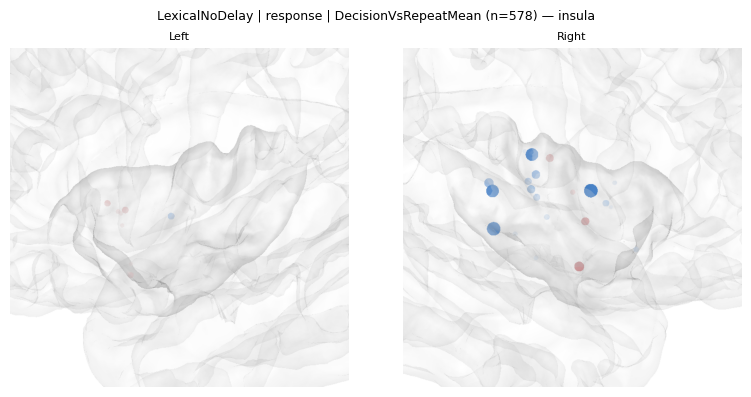

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-18 13:53:43.576 ( 373.287s) [    7F04486D3740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1201c7d0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

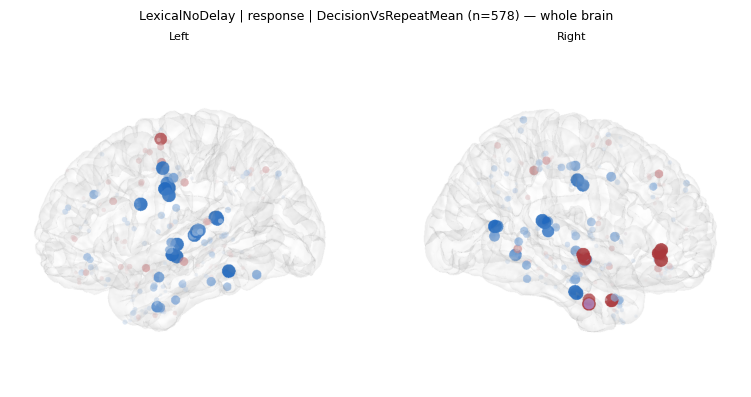

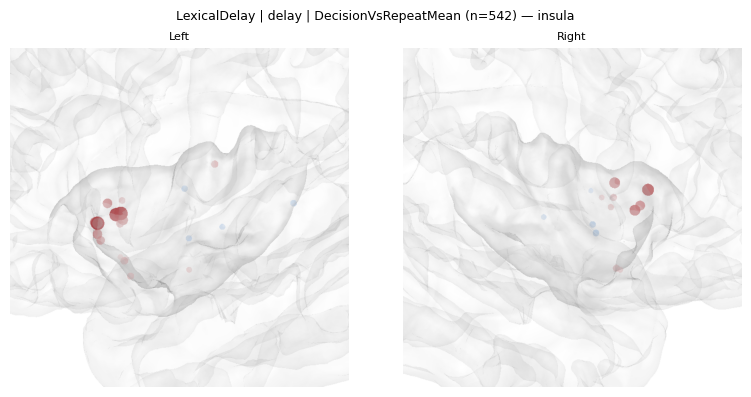

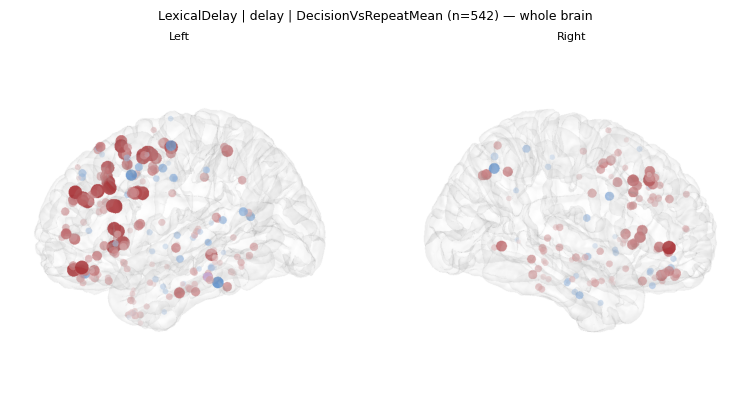

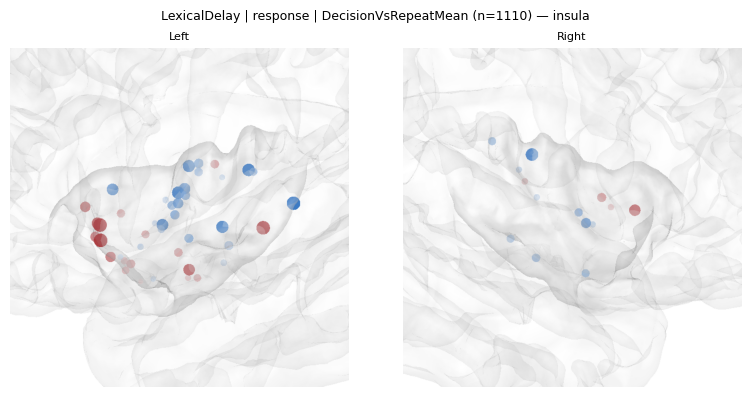

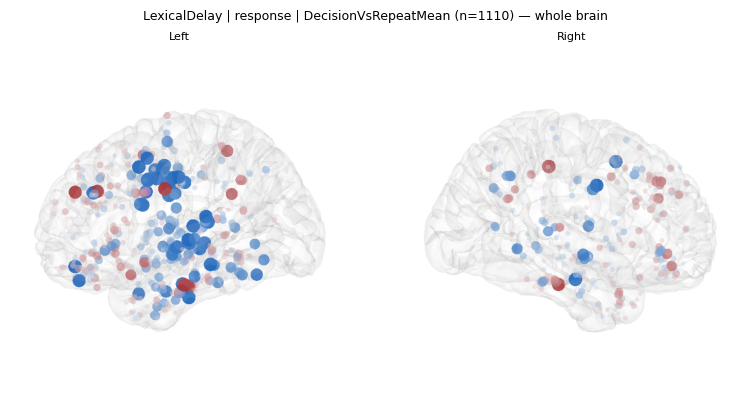

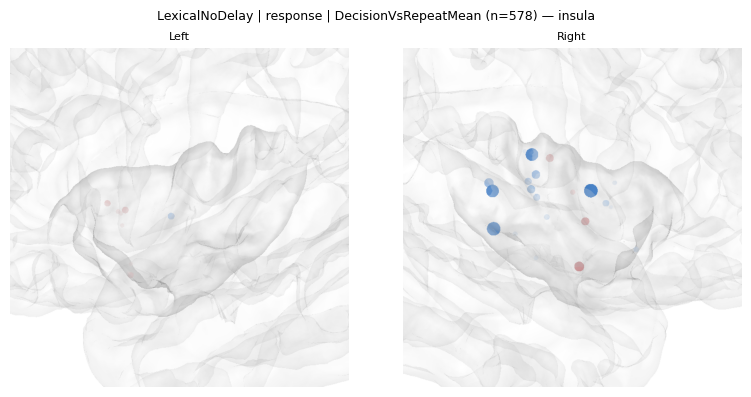

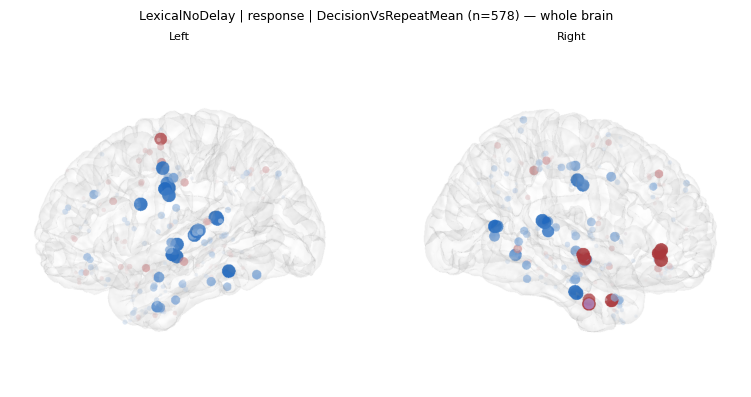

In [14]:
for spec in FIGURE_SPECS:
    task, phase, contrast = parse_figure_spec(spec)
    sig = select_significant(mean_qc, phase=phase, contrast=contrast, tasks=[task])
    title = f'{task} | {phase} | {contrast} (n={sig.channel.nunique()})'
    print(title)
    display(roi_counts(sig).head(10).to_frame('n_channels'))

    fig_i = plot_signed_electrodes_brain(
        sig, view_mode='insula', title=f'{title} — insula', ctx=brain_ctx, red=red, blue=blue
    )
    display(fig_i)

    fig_w = plot_signed_electrodes_brain(
        sig, view_mode='wholebrain', title=f'{title} — whole brain', ctx=brain_ctx, red=red, blue=blue
    )
    display(fig_w)